In [1]:
from perflib.notebook import use_full_width, activate_autoreload
use_full_width()
activate_autoreload()
%matplotlib inline
import bladf
from bladf import Database, Label, utils
from bladf.utils import plot_label
import pandas as pd
import numpy as np
import shutil
import sys
from IPython.display import display
import os
import matplotlib.pyplot as plt
%matplotlib inline
# from IPython.core.display import display, HTML
# display(HTML("<style>.container { width:90% !important; }</style>"))

#ARRET DU CODE AVANT LES ANNEXES, COMMENTER LA CELLULE SI VOUS VOULEZ LES ANNEXES

In [2]:
#Read the csv file containing flight data
flight_df = pd.read_csv("Flight_Data_BXL.csv", delimiter=",")

In [3]:
#Retrieve the data
time_data = flight_df["time"]
MACH_data = flight_df["P_MACH_1"]
CAS_data = flight_df["P_CAS"]
TARGET_CAS_data = flight_df["P_CAS_TGT"]
ZP_data = flight_df["P_STD_ALT"]
TAT_data = flight_df["P_TOTAL_TEMP"]
TSP_data = flight_df["P_EPR_ENG1"]
GW_data = flight_df["P_GW_LBS"]*0.453590
GS_data = flight_df["P_GS1"]
TAS_data = flight_df["P_TAS"]

In [4]:
#Compute Distance from the retrieved data
DT_SECONDS = 0.5
flight_df["distance_step_NM"] = flight_df["P_GS1"] * (DT_SECONDS / 3600)
flight_df["distance_total_NM"] = flight_df["distance_step_NM"].cumsum()
DIST_data = flight_df["distance_total_NM"] 

#Compute the fuel consumption
initial_weight = GW_data.iloc[0]
flight_df["CONSO"] = initial_weight - flight_df["P_GW_LBS"]*0.453590
flight_df["CONSO"] = flight_df["CONSO"].iloc[::-1].reset_index(drop=True) * -1

#Compute DISA from SAT and Pressure Altitude
DISA_data = flight_df["P_SAT1"]-(15 - 1.98*ZP_data/1000)

#Compute the x component of the wind (wind > 0 tailwind and wind <0 headwind, same convention as p_simu)
WIND_data = GS_data - TAS_data

In [135]:
#Run ps_auto flight plan computations with the DPO and Reference model
os.chdir("/projects/fms_exp/uerrxn0d/SCRIPT/BXL_Flight_Analysis/FPLN_FOLDER")
!ps_auto DES_DPO_BXL.txt -s PDV 
!ps_auto DES_REF_BXL.txt -s PDV 
!ps_auto DES_DPO_BXL_MARGES.txt -s PDV
!ps_auto DES_DPO_BXL_NMARGES.txt -s PDV

Shebang line found in 'DES_DPO_BXL.txt'. Restarting ps_auto with options '--shebang DES_DPO_BXL.txt   -s ./BXL_DES_FPLN_DPO.vol --nosort -v -o ./BXL_DES_DPO.csv'.
No sorting option
run_directory=/projects/ae_rech/LINUX_TOOLS/ps_auto_batch
temp_dir=/scratch/uerrxn0d/tmp.BJ2b7o1gxn
input_file=DES_DPO_BXL.txt
template_file=./BXL_DES_FPLN_DPO.vol
Temp directory used: /scratch/uerrxn0d/tmp.BJ2b7o1gxn
Python 3.8.16
Python path: /opt/soft/cdtng/tools/ppack_ac_perfo/1.6-3.8/bin/python 
Temporary path for scenario: /scratch/uerrxn0d/tmp.BJ2b7o1gxn 
Full directory path for run: /projects/ae_rech/LINUX_TOOLS/ps_auto_batch 
Type of scenario: Fichier Plan de Vol Atelier FMS2 
Post-processing options :  
Multiprocessing activated :  
Generating P-SIMU Scenario files in : /scratch/uerrxn0d/tmp.BJ2b7o1gxn/scn
02/12/2026 05:11:17 PM After first generation :                     [nb scenario / nb test point] : 1 / 1
02/12/2026 05:11:17 PM Output parameters Substitution list :{'DIST': 'DIST', 'CONSO': 'CO

Information : le nom du modele [/home/uerrxn0d/MTI/work/A330-743H-VG07-MARGES] correspond a un modele FMS
INHIBITION controle de l enveloppe de vol par integrateur
Fichier disponible sous /projects/fms_exp/uerrxn0d/SIMU/TMP/fms_00000.fms
Generation OK 
Running P_SIMU batch on generated scenario
>> Running p_sexecute_calcul on : fms_00000.fms
Execution OK 
Running results compilation
COLUMNS: orginial=DIST result=DIST
Calling reformator with command line: reformator.pl - DIST CONSO T ZP MACH CAS GW VENT DISA CONF TSPD TSPR GAMA_AIR_GEOM Type_du_segment Type_sous_segment -sep \t -o ./.temp_res_file 
reformator_unicode.pl: warning: multiple blocks of VALEURS in [Sous segment 2.1]. Only the last block will processed (use '-allblocks' to change this behavior).
reformator_unicode.pl: warning: multiple blocks of VALEURS in [Sous segment 2.4]. Only the last block will processed (use '-allblocks' to change this behavior).
Files produced by reformator.pl:  /projects/fms_exp/uerrxn0d/SCRIPT/BXL_F

In [136]:
#Retrieve data from the p_simu result files
DPO_df = pd.read_csv("BXL_DES_DPO.csv", delim_whitespace=True)
DPOM_df = pd.read_csv("BXL_DES_DPO_MARGES.csv", delim_whitespace=True)
DPONM_df = pd.read_csv("BXL_DES_DPO_NMARGES.csv", delim_whitespace=True)
REF_df = pd.read_csv("BXL_DES_REF.csv", delim_whitespace=True)

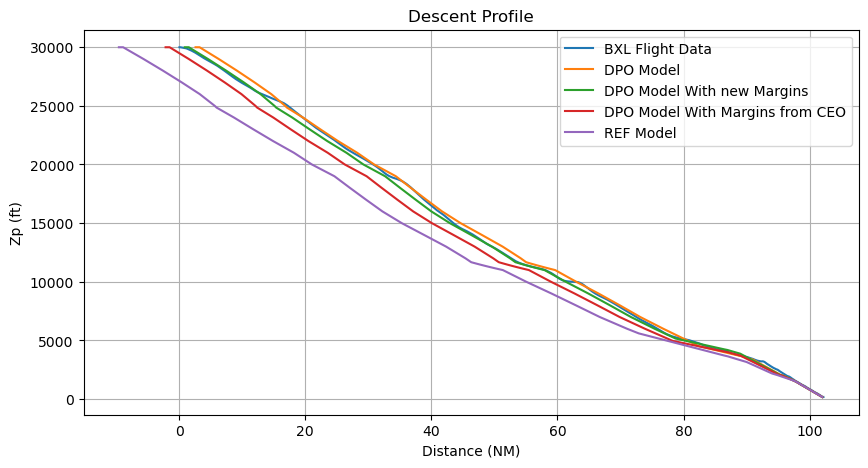

In [137]:
#Plot Zp vs Distance
plt.figure(figsize=(10, 5))

plt.plot(DIST_data, ZP_data, label="BXL Flight Data")
plt.plot(DPO_df["DIST"], DPO_df["ZP"], label="DPO Model")
plt.plot(DPOM_df["DIST"], DPOM_df["ZP"], label="DPO Model With new Margins")
plt.plot(DPONM_df["DIST"], DPONM_df["ZP"], label="DPO Model With Margins from CEO")
plt.plot(REF_df["DIST"], REF_df["ZP"], label="REF Model")

plt.xlabel("Distance (NM)")
plt.ylabel("Zp (ft)")
plt.title("Descent Profile")
plt.legend()
plt.grid(True)

plt.show()

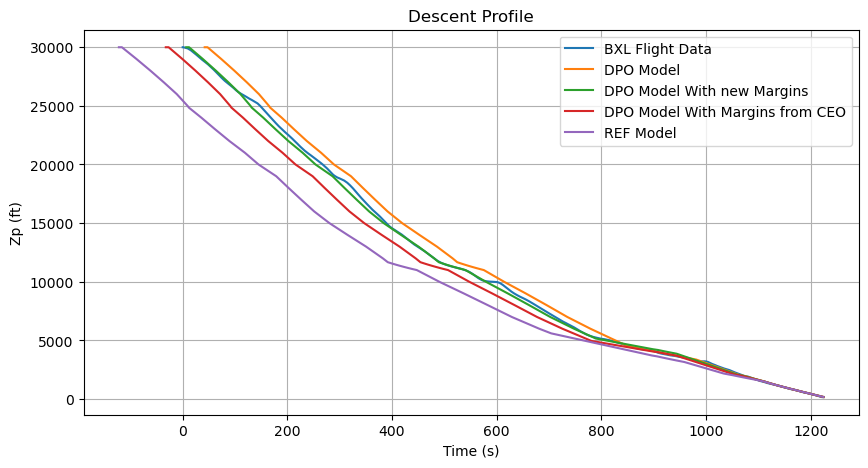

In [138]:
#Plot Zp vs Time
plt.figure(figsize=(10, 5))

plt.plot(time_data, ZP_data, label="BXL Flight Data")
plt.plot(DPO_df["T"]*60, DPO_df["ZP"], label="DPO Model")
plt.plot(DPOM_df["T"]*60, DPOM_df["ZP"], label="DPO Model With new Margins")
plt.plot(DPONM_df["T"]*60, DPONM_df["ZP"], label="DPO Model With Margins from CEO")
plt.plot(REF_df["T"]*60, REF_df["ZP"], label="REF Model")

plt.xlabel("Time (s)")
plt.ylabel("Zp (ft)")
plt.title("Descent Profile")
plt.legend()
plt.grid(True)

plt.show()

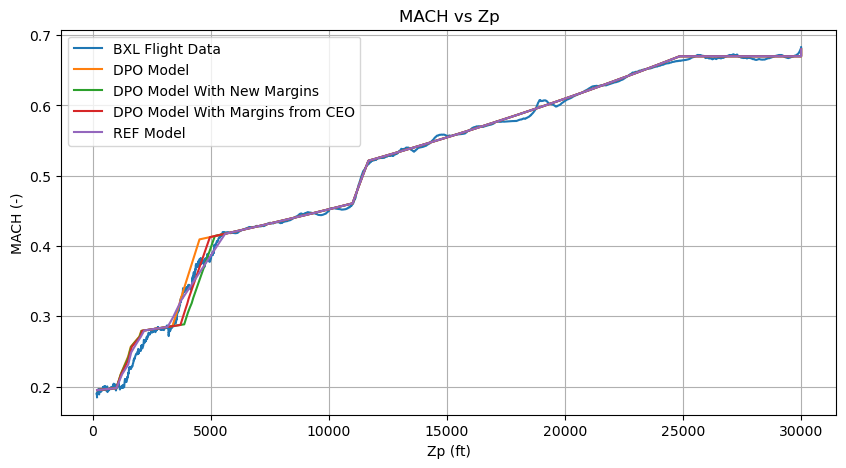

In [139]:
#Plot MACH vs Zp
plt.figure(figsize=(10, 5))

plt.plot(ZP_data, MACH_data, label="BXL Flight Data")
plt.plot(DPO_df["ZP"], DPO_df["MACH"], label="DPO Model")
plt.plot(DPOM_df["ZP"], DPOM_df["MACH"], label="DPO Model With New Margins")
plt.plot(DPONM_df["ZP"], DPONM_df["MACH"], label="DPO Model With Margins from CEO")
plt.plot(REF_df["ZP"], REF_df["MACH"], label="REF Model")

plt.xlabel("Zp (ft)")
plt.ylabel("MACH (-)")
plt.title("MACH vs Zp")
plt.legend()
plt.grid(True)

plt.show()

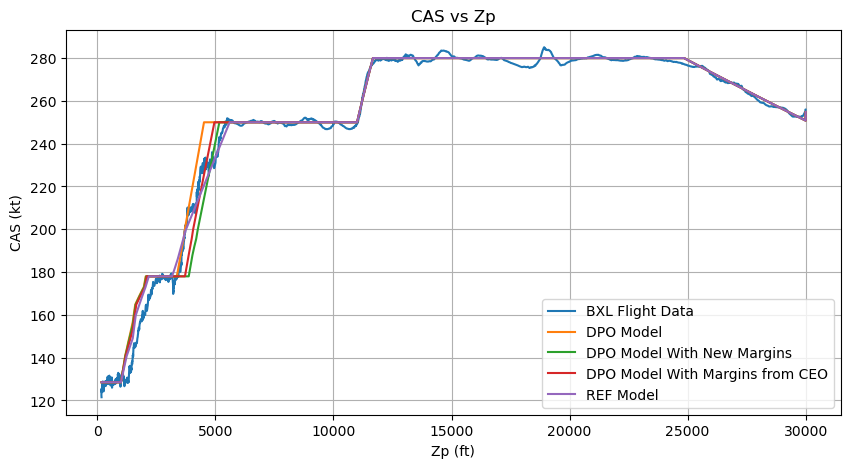

In [140]:
#Plot CAS vs Zp
plt.figure(figsize=(10, 5))

plt.plot(ZP_data, CAS_data, label="BXL Flight Data")
plt.plot(DPO_df["ZP"], DPO_df["CAS"], label="DPO Model")
plt.plot(DPOM_df["ZP"], DPOM_df["CAS"], label="DPO Model With New Margins")
plt.plot(DPONM_df["ZP"], DPONM_df["CAS"], label="DPO Model With Margins from CEO")
plt.plot(REF_df["ZP"], REF_df["CAS"], label="REF Model")

plt.xlabel("Zp (ft)")
plt.ylabel("CAS (kt)")
plt.title("CAS vs Zp")
plt.legend()
plt.grid(True)

plt.show()

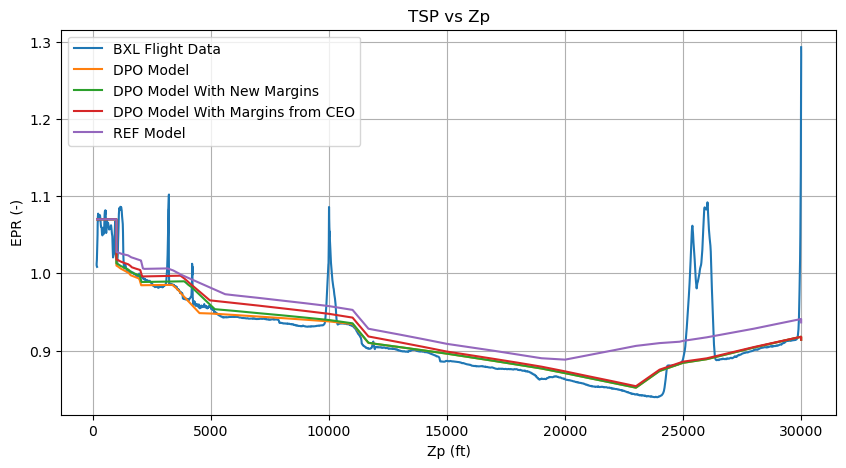

In [141]:
#Plot EPR vs Zp
plt.figure(figsize=(10, 5))

plt.plot(ZP_data, flight_df["P_EPR_ENG1"], label="BXL Flight Data")
plt.plot(DPO_df["ZP"], DPO_df["TSPR"], label="DPO Model")
plt.plot(DPOM_df["ZP"], DPOM_df["TSPR"], label="DPO Model With New Margins")
plt.plot(DPONM_df["ZP"], DPONM_df["TSPR"], label="DPO Model With Margins from CEO")
plt.plot(REF_df["ZP"], REF_df["TSPR"], label="REF Model")

plt.xlabel("Zp (ft)")
plt.ylabel("EPR (-)")
plt.title("TSP vs Zp")
plt.legend()
plt.grid(True)

plt.show()

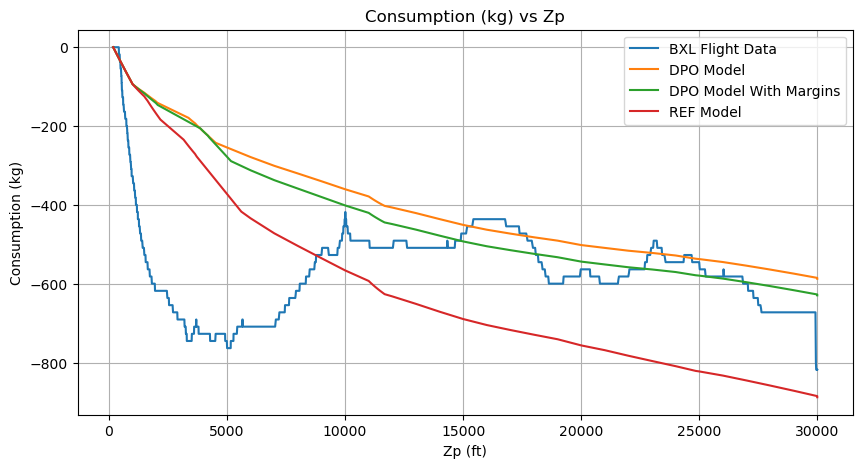

In [142]:
#Plot Consumption vs Zp
plt.figure(figsize=(10, 5))

plt.plot(ZP_data, flight_df["CONSO"], label="BXL Flight Data")
plt.plot(DPO_df["ZP"], DPO_df["CONSO"], label="DPO Model")
plt.plot(DPOM_df["ZP"], DPOM_df["CONSO"], label="DPO Model With Margins")
plt.plot(REF_df["ZP"], REF_df["CONSO"], label="REF Model")

plt.xlabel("Zp (ft)")
plt.ylabel("Consumption (kg)")
plt.title("Consumption (kg) vs Zp")
plt.legend()
plt.grid(True)

plt.show()

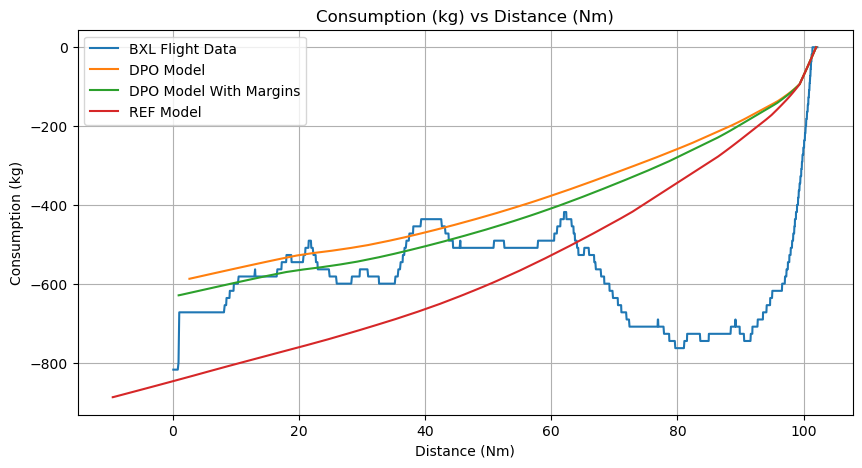

In [143]:
#Plot Consumption vs Dist
plt.figure(figsize=(10, 5))

plt.plot(DIST_data, flight_df["CONSO"], label="BXL Flight Data")
plt.plot(DPO_df["DIST"], DPO_df["CONSO"], label="DPO Model")
plt.plot(DPOM_df["DIST"], DPOM_df["CONSO"], label="DPO Model With Margins")
plt.plot(REF_df["DIST"], REF_df["CONSO"], label="REF Model")

plt.xlabel("Distance (Nm)")
plt.ylabel("Consumption (kg)")
plt.title("Consumption (kg) vs Distance (Nm)")
plt.legend()
plt.grid(True)

plt.show()

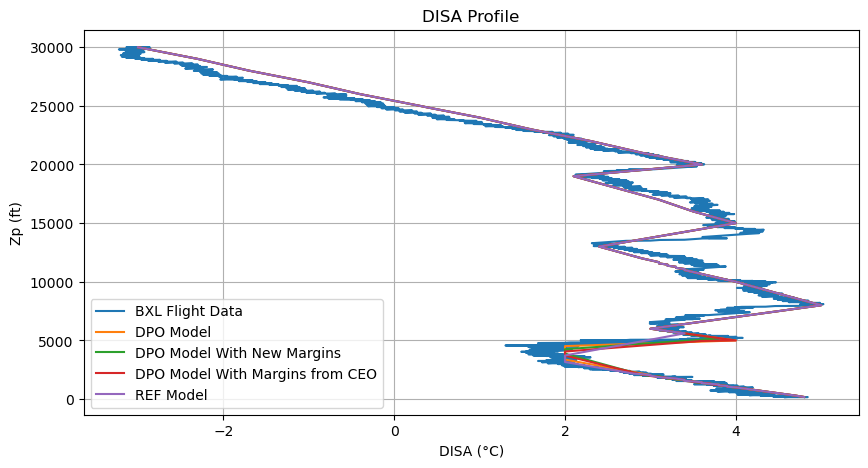

In [144]:
#Plot DISA profile
plt.figure(figsize=(10, 5))

plt.plot(DISA_data, ZP_data, label="BXL Flight Data")
plt.plot(DPO_df["DISA"], DPO_df["ZP"], label="DPO Model")
plt.plot(DPOM_df["DISA"], DPOM_df["ZP"], label="DPO Model With New Margins")
plt.plot(DPONM_df["DISA"], DPONM_df["ZP"], label="DPO Model With Margins from CEO")
plt.plot(REF_df["DISA"], REF_df["ZP"], label="REF Model")

plt.xlabel("DISA (°C)")
plt.ylabel("Zp (ft)")
plt.title("DISA Profile")
plt.legend()
plt.grid(True)

plt.show()

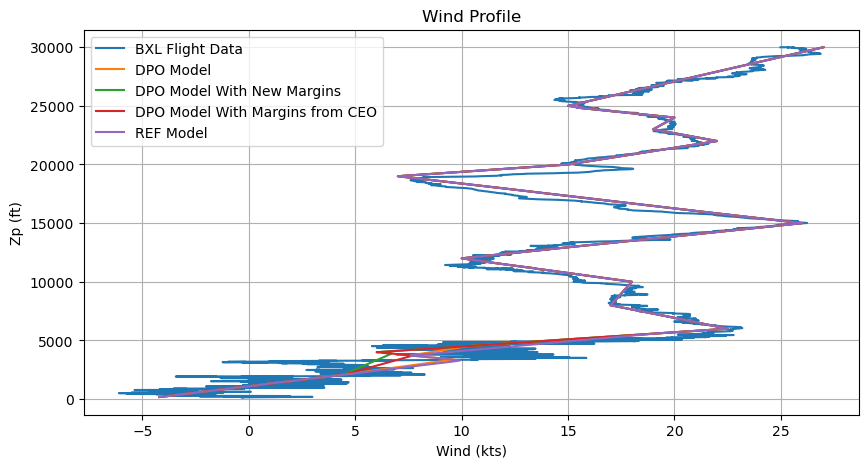

In [145]:
#Plot Wind profile

plt.figure(figsize=(10, 5))

plt.plot(WIND_data, ZP_data, label="BXL Flight Data")
plt.plot(DPO_df["VENT"], DPO_df["ZP"], label="DPO Model")
plt.plot(DPOM_df["VENT"], DPOM_df["ZP"], label="DPO Model With New Margins")
plt.plot(DPONM_df["VENT"], DPONM_df["ZP"], label="DPO Model With Margins from CEO")
plt.plot(REF_df["VENT"], REF_df["ZP"], label="REF Model")

plt.xlabel("Wind (kts)")
plt.ylabel("Zp (ft)")
plt.title("Wind Profile")
plt.legend()
plt.grid(True)

plt.show()